In [23]:
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

In [25]:
DATA_DIR = os.path.expanduser("~/pqc/Signature-RaspberryPi/results")

paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.jsonl")))
paths

['/home/momo/pqc/Signature-RaspberryPi/results/rpi-local_keypair.jsonl',
 '/home/momo/pqc/Signature-RaspberryPi/results/rpi-local_sign.jsonl',
 '/home/momo/pqc/Signature-RaspberryPi/results/rpi-local_verify.jsonl',
 '/home/momo/pqc/Signature-RaspberryPi/results/rpi-local_whole.jsonl']

In [27]:
def read_jsonl(path):
    rows = []
    bad = 0
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                bad += 1
    if bad:
        print(f"⚠️ {os.path.basename(path)} : {bad} lignes JSON invalides ignorées")
    return rows

In [30]:
ops = ["keypair", "sign", "verify", "whole"]
all_rows = []

for p in paths:
    fname = os.path.basename(p).lower()
    op_from_name = next((op for op in ops if op in fname), None)

    for r in read_jsonl(p):
        if "op" not in r and op_from_name:
            r["op"] = op_from_name
        r["_file"] = os.path.basename(p)
        all_rows.append(r)

df = pd.DataFrame(all_rows)
df.head()

⚠️ rpi-local_keypair.jsonl : 1 lignes JSON invalides ignorées


,platform,alg,op,iter,msg_len,time_us,heap_used_before,heap_used_after,rss_kb_before,rss_kb_after,pk_len,sk_len,sig_len,ok,_file,t_keypair_us,t_sign_us,t_verify_us,ok_keypair,ok_sign,ok_verify
0,rpi-local,Falcon-512,keypair,0,0,188157,9568,10176,1816,1884,897,1281,-1,1,rpi-local_keypair.jsonl,NaN,NaN,NaN,NaN,NaN,NaN
1,rpi-local,Falcon-512,keypair,1,0,74216,10176,10464,1884,1884,897,1281,-1,1,rpi-local_keypair.jsonl,NaN,NaN,NaN,NaN,NaN,NaN
2,rpi-local,Falcon-512,keypair,2,0,104040,10464,10520,1884,1884,897,1281,-1,1,rpi-local_keypair.jsonl,NaN,NaN,NaN,NaN,NaN,NaN
3,rpi-local,Falcon-512,keypair,3,0,120303,10520,10576,1884,1888,897,1281,-1,1,rpi-local_keypair.jsonl,NaN,NaN,NaN,NaN,NaN,NaN
4,rpi-local,Falcon-512,keypair,4,0,65999,10576,10632,1888,1888,897,1281,-1,1,rpi-local_keypair.jsonl,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
# Colonnes numériques courantes
num_cols = [
    "iter", "msg_len", "time_us",
    "heap_used_before", "heap_used_after",
    "rss_kb_before", "rss_kb_after",
    "pk_len", "sk_len", "sig_len",
    "t_keypair_us", "t_sign_us", "t_verify_us"
]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Delta mémoire (heap)
if {"heap_used_before", "heap_used_after"}.issubset(df.columns):
    df["heap_delta"] = df["heap_used_after"] - df["heap_used_before"]

df[["platform", "alg", "op", "time_us", "heap_delta"]].head()

,platform,alg,op,time_us,heap_delta
0,rpi-local,Falcon-512,keypair,188157,608
1,rpi-local,Falcon-512,keypair,74216,288
2,rpi-local,Falcon-512,keypair,104040,56
3,rpi-local,Falcon-512,keypair,120303,56
4,rpi-local,Falcon-512,keypair,65999,56


In [32]:
# Vérifier que toutes les ops sont là
df.groupby("op").size()

op
keypair    400
sign       400
verify     400
whole      400
dtype: int64

In [33]:
# Algorithmes détectés
sorted(df["alg"].dropna().unique())

['Falcon-512',
 'Falcon-padded-512',
 'MAYO-1',
 'ML-DSA-44',
 'SPHINCS+-SHA2-128f-simple',
 'SPHINCS+-SHA2-128s-simple',
 'SPHINCS+-SHAKE-128f-simple',
 'SPHINCS+-SHAKE-128s-simple']

In [34]:
op_order = ["keypair", "sign", "verify", "whole"]
df["op"] = df["op"].str.lower()

# Temps
time_agg = (
    df.dropna(subset=["alg", "op", "time_us"])
      .groupby(["alg", "op"])["time_us"]
      .median()
      .reset_index()
)

# Mémoire
mem_agg = (
    df.dropna(subset=["alg", "op", "heap_delta"])
      .groupby(["alg", "op"])["heap_delta"]
      .median()
      .reset_index()
)

time_pivot = time_agg.pivot(index="alg", columns="op", values="time_us").reindex(columns=op_order)
mem_pivot  = mem_agg.pivot(index="alg", columns="op", values="heap_delta").reindex(columns=op_order)

time_pivot

op,keypair,sign,verify,whole
alg,,,,
Falcon-512,99837.5,25743.0,543.0,127212.0
Falcon-padded-512,103818.0,25238.5,624.0,133723.0
MAYO-1,15181.0,25895.0,13259.0,55426.5
ML-DSA-44,1857.0,3644.0,1869.5,7892.5
SPHINCS+-SHA2-128f-simple,8180.0,189935.5,11117.0,212351.0
SPHINCS+-SHA2-128s-simple,526270.5,4123838.5,4062.0,4668572.5
SPHINCS+-SHAKE-128f-simple,76494.5,1915099.5,117021.0,2045639.5
SPHINCS+-SHAKE-128s-simple,5089898.5,40198010.5,37568.0,45976408.5


In [35]:
def plot_grouped_bars(pivot_df, title, ylabel, logy=False):
    pivot_df = pivot_df.dropna(how="all")
    algos = pivot_df.index.tolist()
    ops = pivot_df.columns.tolist()

    x = np.arange(len(algos))
    width = 0.18

    plt.figure(figsize=(max(10, len(algos)*0.6), 5))
    for i, op in enumerate(ops):
        values = pivot_df[op].values
        plt.bar(x + (i - (len(ops)-1)/2)*width, values, width=width, label=op)

    plt.xticks(x, algos, rotation=45, ha="right")
    plt.xlabel("Algorithme")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    if logy:
        plt.yscale("log")
    plt.tight_layout()
    plt.show()

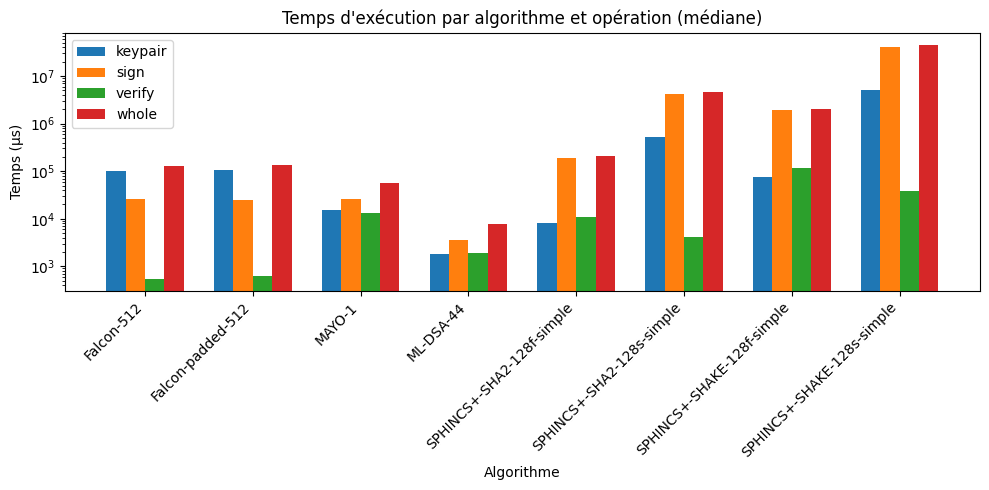

In [36]:
plot_grouped_bars(
    time_pivot,
    title="Temps d'exécution par algorithme et opération (médiane)",
    ylabel="Temps (µs)",
    logy=True   # recommandé (SPHINCS+ très lent)
)

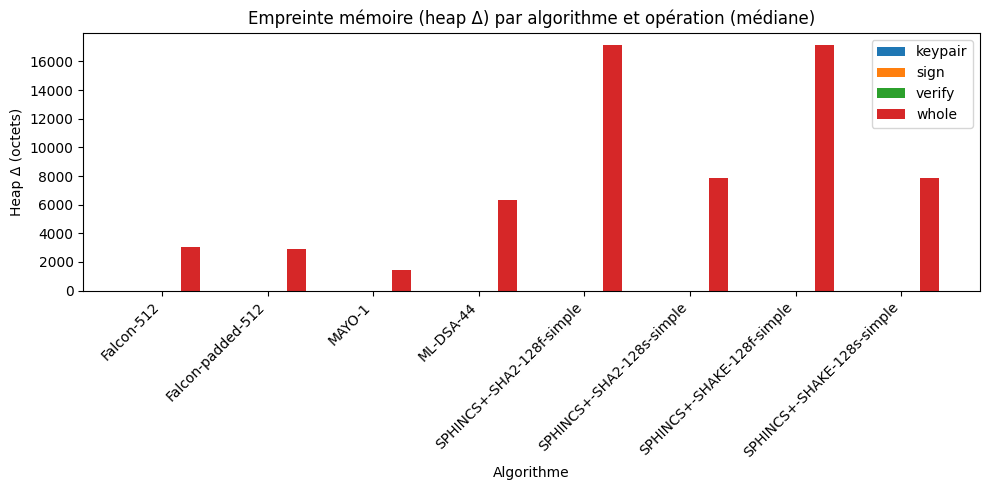

In [37]:
plot_grouped_bars(
    mem_pivot,
    title="Empreinte mémoire (heap Δ) par algorithme et opération (médiane)",
    ylabel="Heap Δ (octets)",
    logy=False
)